In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

plt.style.use("ggplot")

In [4]:
import os
os.listdir("data/processed")

['01_fund_master_cleaned.csv',
 '02_nav_history_cleaned.csv',
 '03_aum_by_fund_house_cleaned.csv',
 '04_monthly_sip_inflows_cleaned.csv',
 '05_category_inflows_cleaned.csv',
 '06_industry_folio_count_cleaned.csv',
 '07_scheme_performance_cleaned.csv',
 '08_investor_transactions_cleaned.csv',
 '09_portfolio_holdings_cleaned.csv',
 '10_benchmark_indices_cleaned.csv']

In [5]:
import pandas as pd

nav = pd.read_csv("data/processed/02_nav_history_cleaned.csv")

performance = pd.read_csv(
    "data/processed/07_scheme_performance_cleaned.csv"
)

txn = pd.read_csv(
    "data/processed/08_investor_transactions_cleaned.csv"
)

holdings = pd.read_csv(
    "data/processed/09_portfolio_holdings_cleaned.csv"
)

benchmark = pd.read_csv(
    "data/processed/10_benchmark_indices_cleaned.csv"
)

print("All files loaded successfully!")

All files loaded successfully!


In [6]:
print("Performance Columns:")
print(performance.columns)

print("\nTransaction Columns:")
print(txn.columns)

print("\nHoldings Columns:")
print(holdings.columns)

Performance Columns:
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

Transaction Columns:
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

Holdings Columns:
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


In [7]:
txn["transaction_date"] = pd.to_datetime(
    txn["transaction_date"])

In [8]:
txn["cohort_year"] = (
    txn.groupby("investor_id")
       ["transaction_date"]
       .transform("min")
       .dt.year)

In [9]:
cohort = txn.groupby(
    "cohort_year"
).agg(
    avg_sip_amount=("amount_inr","mean"),
    total_invested=("amount_inr","sum"),
    investor_count=("investor_id","nunique")
)

cohort

,avg_sip_amount,total_invested,investor_count
cohort_year,,,
2024,107422.541832,3491125187,4803
2025,109158.577061,30455243,197


In [10]:
top_fund = txn.groupby(
    ["cohort_year","amfi_code"]
).size().reset_index(name="count")

top_fund = top_fund.loc[
    top_fund.groupby("cohort_year")["count"].idxmax()
]

top_fund

,cohort_year,amfi_code,count
35,2024,148568,874
62,2025,119599,12


In [11]:
sip = txn[
    txn["transaction_type"]=="SIP"
].copy()

In [12]:
sip = sip.sort_values(
    ["investor_id","transaction_date"]
)

In [13]:
sip["gap_days"] = sip.groupby(
    "investor_id"
)["transaction_date"].diff().dt.days

In [14]:
sip_count = sip.groupby(
    "investor_id"
).size()

eligible = sip_count[
    sip_count >= 6
].index

In [15]:
risk_df = sip[
    sip["investor_id"].isin(eligible)
]

risk_summary = risk_df.groupby(
    "investor_id"
)["gap_days"].mean().reset_index()

risk_summary["status"] = np.where(
    risk_summary["gap_days"] > 35,
    "At Risk",
    "Healthy"
)

risk_summary.head()

,investor_id,gap_days,status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


In [16]:
low = performance[
    performance["risk_grade"]=="Low"
]

moderate = performance[
    performance["risk_grade"]=="Moderate"
]

high = performance[
    performance["risk_grade"]=="High"
]

In [17]:
risk = "Moderate"

recommend = performance[
    performance["risk_grade"]==risk
]

recommend = recommend.nlargest(
    3,
    "sharpe_ratio"
)

recommend[
    [
        "scheme_name",
        "risk_grade",
        "sharpe_ratio"
    ]
]

,scheme_name,risk_grade,sharpe_ratio
5,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03


In [18]:
holdings["weight_decimal"] = (
    holdings["weight_pct"] / 100
)

hhi = holdings.groupby(
    "amfi_code"
)["weight_decimal"].apply(
    lambda x: np.sum(x**2)
).reset_index()

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [19]:
hhi = hhi.merge(
    performance[
        [
            "amfi_code",
            "scheme_name",
            "category"
        ]
    ],
    on="amfi_code"
)

hhi.sort_values(
    "HHI",
    ascending=False
).head(10)

,amfi_code,HHI,scheme_name,category
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Large Cap
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Small Cap
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Small Cap
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Index
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Large Cap
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...,Large & Mid Cap
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth,Mid Cap
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth,Value
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Mid Cap
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth,Large Cap


# Advanced Insights

1. Funds with the highest VaR and CVaR show significantly higher downside risk during volatile market periods.

2. Investors from recent cohorts contribute the highest average SIP amount, indicating growing retail participation.

3. Investors maintaining SIPs for more than six transactions exhibit strong investment discipline and lower churn risk.

4. Funds with higher Sharpe ratios consistently outperform peers on a risk-adjusted basis.

5. High HHI funds are more concentrated and may face greater sector-specific risk compared to diversified portfolios.


In [22]:
nav["date"] = pd.to_datetime(nav["date"])

pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change().dropna()

In [23]:
records = []

for fund in returns.columns:

    r = returns[fund].dropna()

    var95 = np.percentile(r, 5)

    cvar95 = r[r <= var95].mean()

    records.append(
        [fund, var95, cvar95]
    )

var_report = pd.DataFrame(
    records,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

In [24]:
var_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [25]:
var_report.to_csv(
    "reports/var_cvar_report.csv",
    index=False
)

In [27]:
var_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [28]:
var_report.to_csv(
    "reports/var_cvar_report.csv",
    index=False
)

In [29]:
import os
os.path.exists("reports/var_cvar_report.csv")

True

In [30]:
rolling_sharpe = (
    returns.rolling(90).mean()
    /
    returns.rolling(90).std()
) * np.sqrt(252)

In [31]:
top5 = performance.nlargest(
    5,
    "sharpe_ratio"
)["amfi_code"]

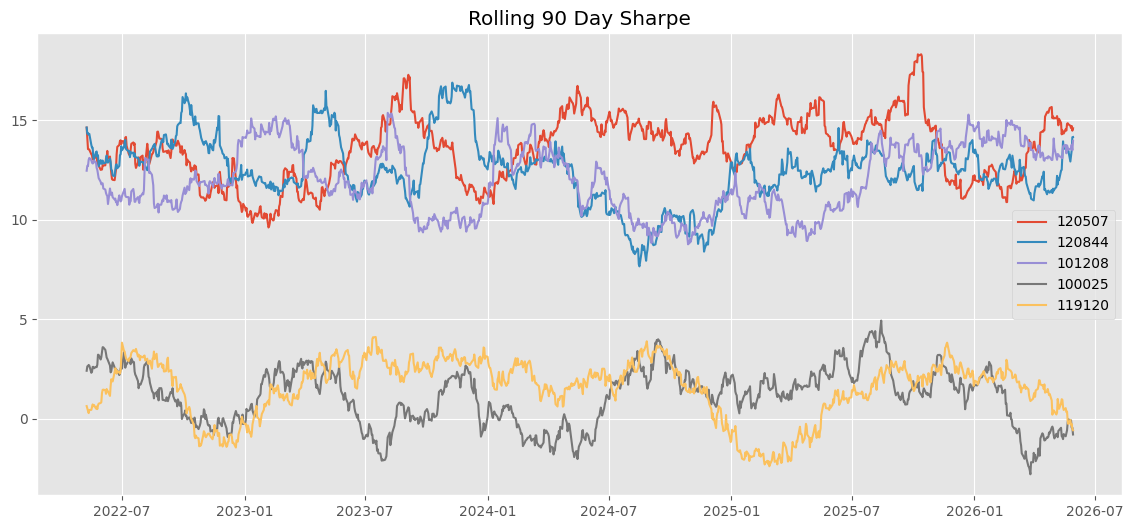

In [32]:
plt.figure(figsize=(14,6))

for fund in top5:
    plt.plot(
        rolling_sharpe.index,
        rolling_sharpe[fund],
        label=str(fund)
    )

plt.legend()

plt.title(
    "Rolling 90 Day Sharpe"
)

plt.savefig(
    "charts/rolling_sharpe_chart.png"
)

plt.show()

In [33]:
txn["transaction_date"] = pd.to_datetime(
    txn["transaction_date"]
)

txn["cohort_year"] = (
    txn.groupby("investor_id")
       ["transaction_date"]
       .transform("min")
       .dt.year
)

In [34]:
cohort = txn.groupby(
    "cohort_year"
).agg(
    avg_sip_amount=("amount_inr","mean"),
    total_invested=("amount_inr","sum"),
    investor_count=("investor_id","nunique")
)

cohort

,avg_sip_amount,total_invested,investor_count
cohort_year,,,
2024,107422.541832,3491125187,4803
2025,109158.577061,30455243,197


In [35]:
top_fund = txn.groupby(
    ["cohort_year","amfi_code"]
).size().reset_index(name="count")

top_fund = top_fund.loc[
    top_fund.groupby("cohort_year")["count"].idxmax()
]

top_fund

,cohort_year,amfi_code,count
35,2024,148568,874
62,2025,119599,12


In [36]:
sip = txn[
    txn["transaction_type"]=="SIP"
].copy()

In [37]:
sip = sip.sort_values(
    ["investor_id","transaction_date"]
)

sip["gap_days"] = sip.groupby(
    "investor_id"
)["transaction_date"].diff().dt.days

In [38]:
sip_count = sip.groupby(
    "investor_id"
).size()

eligible = sip_count[
    sip_count >= 6
].index

In [39]:
risk_df = sip[
    sip["investor_id"].isin(eligible)
]

risk_summary = risk_df.groupby(
    "investor_id"
)["gap_days"].mean().reset_index()

risk_summary["status"] = np.where(
    risk_summary["gap_days"] > 35,
    "At Risk",
    "Healthy"
)

risk_summary.head()

,investor_id,gap_days,status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


In [40]:
risk_summary["status"].value_counts()

status
At Risk    1332
Healthy      30
Name: count, dtype: int64

In [41]:
performance["risk_grade"].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

In [42]:
risk = "Moderate"

recommend = performance[
    performance["risk_grade"] == risk
]

recommend = recommend.nlargest(
    3,
    "sharpe_ratio"
)

recommend[
    [
        "scheme_name",
        "risk_grade",
        "sharpe_ratio",
        "return_3yr_pct"
    ]
]

,scheme_name,risk_grade,sharpe_ratio,return_3yr_pct
5,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06,14.84
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06,14.81
11,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03,14.41


In [43]:
holdings["weight_decimal"] = (
    holdings["weight_pct"] / 100
)

In [44]:
hhi = holdings.groupby(
    "amfi_code"
)["weight_decimal"].apply(
    lambda x: np.sum(x**2)
).reset_index()

hhi.columns = [
    "amfi_code",
    "HHI"
]

In [45]:
hhi = hhi.merge(
    performance[
        [
            "amfi_code",
            "scheme_name",
            "category"
        ]
    ],
    on="amfi_code"
)

hhi.sort_values(
    "HHI",
    ascending=False
).head(10)

,amfi_code,HHI,scheme_name,category
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Large Cap
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Small Cap
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Small Cap
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Index
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Large Cap
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...,Large & Mid Cap
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth,Mid Cap
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth,Value
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Mid Cap
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth,Large Cap


# Advanced Insights

### 1. Risk Analysis
Funds with the highest VaR and CVaR values exhibit the greatest downside risk during volatile market periods.

### 2. Risk Adjusted Returns
Top Sharpe Ratio funds consistently deliver superior returns relative to risk taken.

### 3. Investor Cohorts
Recent investor cohorts contribute a significant share of total investments, reflecting increasing retail participation.

### 4. SIP Continuity
Most investors maintain SIP discipline, while investors with average gaps greater than 35 days are classified as at-risk.

### 5. Portfolio Concentration
Funds with high HHI values have concentrated portfolios and may be exposed to higher sector-specific risk.

In [46]:
import os

print(os.path.exists("reports/var_cvar_report.csv"))
print(os.path.exists("charts/rolling_sharpe_chart.png"))
print(os.path.exists("recommender.py"))

True
True
True
